# EDA Exploration

This notebook is the trial-and-error workspace for Part II (see `CONVENTIONS.md`). Findings are moved, cleaned up, to `EDA_report.md` once the exploration is done.

## Step A: initial diagnostic — dtypes, duplicates, nulls (lightweight)

A quick first look at the raw dataset before any deeper analysis: shape and column types, duplicate rows, and a null-count table. No imputation, target comparisons, or plots yet.

In [1]:
import pandas as pd

df = pd.read_csv("../data/Food_Delivery_Times.csv")
print(f"Shape: {df.shape}")
df.dtypes

Shape: (1000, 9)


Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

In [2]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


In [3]:
null_summary = pd.DataFrame({
    "n_nulls": df.isnull().sum(),
    "pct_nulls": (df.isnull().sum() / len(df) * 100).round(2),
})
null_summary

,n_nulls,pct_nulls
Order_ID,0,0.0
Distance_km,0,0.0
Weather,30,3.0
Traffic_Level,30,3.0
Time_of_Day,30,3.0
Vehicle_Type,0,0.0
Preparation_Time_min,0,0.0
Courier_Experience_yrs,30,3.0
Delivery_Time_min,0,0.0


## Step B: null overlap check

`Weather`, `Traffic_Level`, `Time_of_Day`, and `Courier_Experience_yrs` each have exactly 30 nulls. This checks whether that is the same 30 rows across all four columns, or unrelated rows that coincidentally add up to the same count.

In [4]:
null_cols = ["Weather", "Traffic_Level", "Time_of_Day", "Courier_Experience_yrs"]

n_any_null = df[null_cols].isnull().any(axis=1).sum()
n_all_null = df[null_cols].isnull().all(axis=1).sum()

print(f"Rows with a null in at least one of the 4 columns: {n_any_null}")
print(f"Rows with a null in all 4 columns simultaneously: {n_all_null}")

Rows with a null in at least one of the 4 columns: 117
Rows with a null in all 4 columns simultaneously: 0


In [5]:
n_null_per_row = df[null_cols].isnull().sum(axis=1)
n_null_per_row[n_null_per_row > 0].value_counts().sort_index().rename("n_rows").to_frame()

,n_rows
1,114
2,3


## Step C: missingness mechanism per column (MCAR / MAR / MNAR)

For each of the 4 columns with nulls, this checks two kinds of evidence separately: whether rows with a null differ in `Delivery_Time_min` (the target) from rows without one, and whether the null rate itself concentrates in 1-2 candidate variables rather than being spread evenly. Category sizes are large enough here (roughly 85-500 rows per category) that a null-rate difference of a couple of percentage points is unlikely to be pure noise, though this is a descriptive check, not a formal statistical test.

### `Weather`

In [6]:
col = "Weather"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Weather,,,,
False,56.810309,56.0,22.034664,970
True,54.200000,53.5,23.462957,30


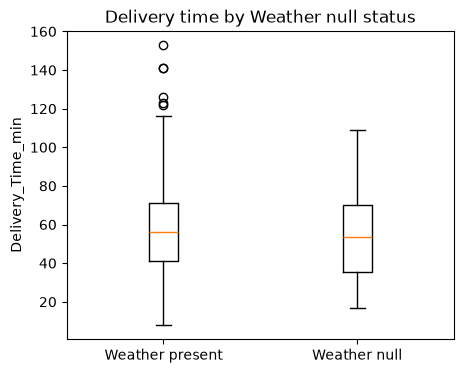

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [8]:
pd.DataFrame({
    "null_rate_by_Traffic_Level": df.groupby("Traffic_Level")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Vehicle_Type": df.groupby("Vehicle_Type")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(               null_rate_by_Traffic_Level
 Traffic_Level                            
 High                                0.030
 Low                                 0.023
 Medium                              0.038,
               null_rate_by_Vehicle_Type
 Vehicle_Type                           
 Bike                              0.018
 Car                               0.046
 Scooter                           0.040)

**Classification: MCAR.** `Delivery_Time_min` is nearly identical between the two groups (54.2 vs 56.8 min, well within one standard deviation), and the null rate barely moves across `Traffic_Level` (2.3-3.8%) or `Vehicle_Type` (1.8-4.6%) — no candidate shows a consistent, sizeable split. The missingness looks unrelated to any observed variable checked here.

### `Traffic_Level`

In [9]:
col = "Traffic_Level"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Traffic_Level,,,,
False,56.567010,55.0,21.944769,970
True,62.066667,60.0,25.672921,30


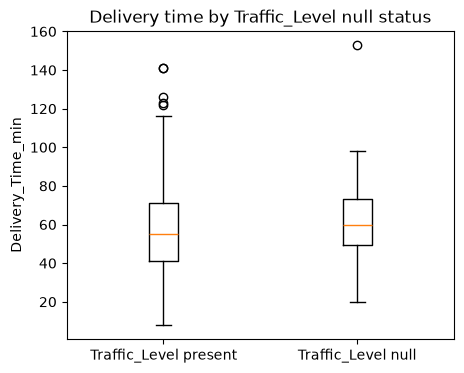

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [11]:
pd.DataFrame({
    "null_rate_by_Vehicle_Type": df.groupby("Vehicle_Type")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Weather": df.groupby("Weather")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(              null_rate_by_Vehicle_Type
 Vehicle_Type                           
 Bike                              0.020
 Car                               0.036
 Scooter                           0.043,
          null_rate_by_Weather
 Weather                      
 Clear                   0.036
 Foggy                   0.010
 Rainy                   0.029
 Snowy                   0.031
 Windy                   0.031)

**Classification: MAR (leaning).** Rows with a null `Traffic_Level` average 62.1 min vs. 56.6 min for the rest — a real gap, and one tied to `Delivery_Time_min`, an observed variable, which is the textbook signature of MAR rather than MCAR. `Vehicle_Type` reinforces this: the null rate roughly doubles from `Bike` (2.0%) to `Scooter` (4.3%). MNAR cannot be ruled out (e.g. traffic readings failing specifically during severe congestion), but there is no way to test that directly since the true missing values are unobserved — the evidence in hand only supports dependence on observed variables.

### `Time_of_Day`

In [12]:
col = "Time_of_Day"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Time_of_Day,,,,
False,56.440206,55.0,21.572424,970
True,66.166667,62.5,33.703661,30


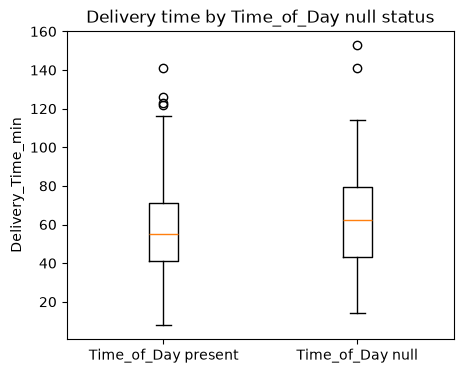

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [14]:
pd.DataFrame({
    "null_rate_by_Weather": df.groupby("Weather")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Traffic_Level": df.groupby("Traffic_Level")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(         null_rate_by_Weather
 Weather                      
 Clear                   0.030
 Foggy                   0.019
 Rainy                   0.020
 Snowy                   0.031
 Windy                   0.062,
                null_rate_by_Traffic_Level
 Traffic_Level                            
 High                                0.020
 Low                                 0.042
 Medium                              0.023)

**Classification: MAR.** This is the clearest signal of the four: rows with a null `Time_of_Day` average 66.2 min vs. 56.4 min for the rest (a ~10 min gap), and their spread is also much wider (std ~33.7 vs ~21.6) — the null group skews toward slow, high-variance deliveries. Two candidates support this: `Weather` shows `Windy` at a 6.2% null rate vs. 2-3% for the other conditions, and `Traffic_Level` shows `Low` at 4.2% vs. 2.0-2.3% for `Medium`/`High`. Missingness here tracks observed variables (weather, traffic, and the target itself) rather than looking random.

### `Courier_Experience_yrs`

In [15]:
col = "Courier_Experience_yrs"
df.groupby(df[col].isnull())["Delivery_Time_min"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Courier_Experience_yrs,,,,
False,56.743299,56.0,22.071352,970
True,56.366667,53.5,22.430711,30


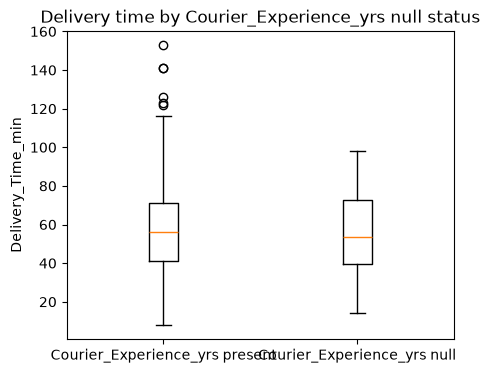

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(
    [df.loc[df[col].notnull(), "Delivery_Time_min"], df.loc[df[col].isnull(), "Delivery_Time_min"]],
    tick_labels=[f"{col} present", f"{col} null"],
)
ax.set_ylabel("Delivery_Time_min")
ax.set_title(f"Delivery time by {col} null status")
plt.show()

In [17]:
pd.DataFrame({
    "null_rate_by_Vehicle_Type": df.groupby("Vehicle_Type")[col].apply(lambda s: s.isnull().mean()),
}).round(3), pd.DataFrame({
    "null_rate_by_Weather": df.groupby("Weather")[col].apply(lambda s: s.isnull().mean()),
}).round(3)

(              null_rate_by_Vehicle_Type
 Vehicle_Type                           
 Bike                              0.030
 Car                               0.015
 Scooter                           0.040,
          null_rate_by_Weather
 Weather                      
 Clear                   0.032
 Foggy                   0.019
 Rainy                   0.029
 Snowy                   0.052
 Windy                   0.010)

**Classification: MCAR.** `Delivery_Time_min` is virtually the same whether `Courier_Experience_yrs` is null or not (56.4 vs. 56.7 min). `Vehicle_Type` shows some spread (`Car` 1.5% vs. `Scooter` 4.0%) and `Weather` too (`Windy` 1.0% vs. `Snowy` 5.2%), but neither is consistent with the other or with the target, which looks more like noise across small null counts per category than a real pattern. A plausible business story exists (experience not yet recorded for brand-new couriers) but nothing in the observed data confirms or contradicts it — nothing here supports MAR or MNAR over MCAR.

## Step C summary

In [18]:
pd.DataFrame([
    {
        "column": "Weather",
        "classification": "MCAR",
        "justification": "No target gap (54.2 vs 56.8 min) and no consistent split across Traffic_Level or Vehicle_Type.",
    },
    {
        "column": "Traffic_Level",
        "classification": "MAR (leaning)",
        "justification": "Target gap (62.1 vs 56.6 min) plus null rate doubling Bike->Scooter (2.0% -> 4.3%).",
    },
    {
        "column": "Time_of_Day",
        "classification": "MAR",
        "justification": "Largest target gap (66.2 vs 56.4 min, wider spread) and higher null rate under Windy weather and Low traffic.",
    },
    {
        "column": "Courier_Experience_yrs",
        "classification": "MCAR",
        "justification": "No target gap (56.4 vs 56.7 min); category-level spread looks like noise, not a consistent pattern.",
    },
])

,column,classification,justification
0,Weather,MCAR,No target gap (54.2 vs 56.8 min) and no consis...
1,Traffic_Level,MAR (leaning),Target gap (62.1 vs 56.6 min) plus null rate d...
2,Time_of_Day,MAR,"Largest target gap (66.2 vs 56.4 min, wider sp..."
3,Courier_Experience_yrs,MCAR,No target gap (56.4 vs 56.7 min); category-lev...
